In [ ]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seed = 42
n=5

df_results_grid_actions = pd.read_csv('C:/Users/Teresa/Documents/GitHub/navsim/tmp/tmpTeresa/resultados_grid/resultados_algoritmo_PPO.csv')

In [ ]:
def get_group(value):
    if "_hover" in value:
        return "Hover"
    elif "_reach" in value:
        return "Reach"

df_results_grid_actions["tarea"] = df_results_grid_actions["id_run_name"].apply(get_group)

In [101]:
df_copy = df_results_grid_actions.copy()
df_results_grid_actions.sample(n, random_state=seed)

,id_run_name,iteration,reward,tarea
33,ppo_random_4,0,-0.017479,Reach
108,ppo_random_15,400,-0.132584,Reach
240,ppo_random_31,100,-0.632822,Reach
259,ppo_random_33,900,-1.167336,Reach
154,ppo_random_21,400,-0.806848,Reach


``Me quedo con los 5 modelos con mayor reward de cada tarea``

In [102]:
df_results_grid_actions.set_index(['tarea','id_run_name'],inplace=True)
top5 = (
    df_results_grid_actions.groupby(level="tarea")
      .apply(lambda g: g.sort_values("reward", ascending=False).head(5))
)

# Eliminar el nivel adicional que introduce groupby+apply
top5.index = top5.index.droplevel(0)

top5

iteration    reward
tarea id_run_name                       
Reach ppo_random_22       1000  2.619776
      ppo_random_22        900  2.594173
      ppo_random_22        800  2.554958
      ppo_random_5         800  2.553692
      ppo_random_5         700  2.542543

``Muestro la reward media por experimento y acción: hay valores extremos``
Esto nos indica qué modelo, de media, tiene un mejor aprendizaje.

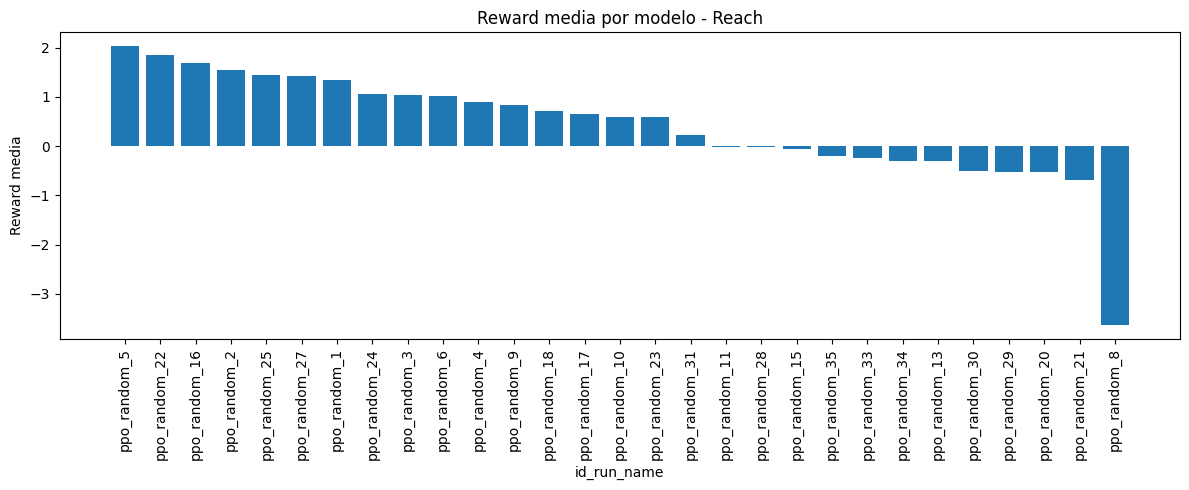

In [103]:
mean_rewards = df_results_grid_actions.groupby(["tarea", "id_run_name"])["reward"].mean()

for tarea, subdf in mean_rewards.groupby(level="tarea"):
    plt.figure(figsize=(12,5))
    
    # Convertir a DataFrame y resetear index para graficar
    plot_df = subdf.reset_index()
    plot_df = plot_df.sort_values("reward", ascending=False)
    
    plt.bar(plot_df["id_run_name"], plot_df["reward"])
    plt.title(f"Reward media por modelo - {tarea}")
    plt.xlabel("id_run_name")
    plt.ylabel("Reward media")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


``AUC``: Nos permite identificar qué modelo aprende con mayor rapidez, y obtiene mayor reward general a lo largo del 
entrenamiento. Mostraremos los 5 mejores para cada tarea.

In [104]:
auc_results = []

for (tarea, run_name), subdf in df_results_grid_actions.groupby(["tarea", "id_run_name"]):
    x = subdf["iteration"].values
    y = subdf["reward"].values
    
    # Área bajo la curva usando regla del trapecio
    auc = np.trapz(y, x)
    
    auc_results.append([tarea, run_name, auc])

auc_df = pd.DataFrame(auc_results, columns=["tarea", "id_run_name", "AUC"])

auc_df = auc_df.set_index(["tarea", "id_run_name"])

top5_auc = (
    auc_df.groupby(level="tarea")
          .apply(lambda g: g.sort_values("AUC", ascending=False).head(5))
)
top5_auc.index = top5_auc.index.droplevel(0)
top5_auc


AUC
tarea id_run_name               
Reach ppo_random_5   2107.258561
      ppo_random_22  1899.652816
      ppo_random_16  1746.713819
      ppo_random_2   1622.608840
      ppo_random_27  1492.879205

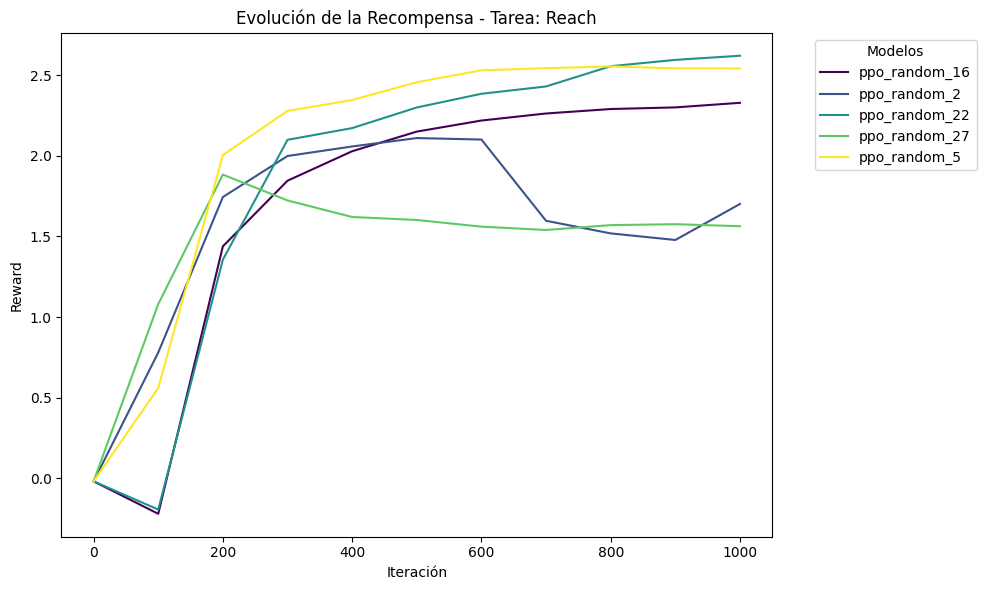

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Aseguramos que `top5_auc` tenga 'tarea' e 'id_run_name' como columnas, no solo en el índice
top5_auc_reset = top5_auc.reset_index()

# Convertir el índice jerárquico en columnas (para acceder a 'tarea' y 'id_run_name')
df_copy_reset = df_copy.reset_index()

# Unimos `top5_auc_reset` con `df_copy_reset` en las columnas comunes: 'tarea' y 'id_run_name'
merged_df = pd.merge(df_copy_reset, top5_auc_reset[['tarea', 'id_run_name']], on=['tarea', 'id_run_name'], how='inner')

# Usamos una lista de colores para asignar un color diferente a cada modelo
colors = plt.cm.viridis(np.linspace(0, 1, len(merged_df['id_run_name'].unique())))

# Ahora, procedemos a graficar
for tarea, task_df in merged_df.groupby('tarea'):
    plt.figure(figsize=(10, 6))
    
    # Iteramos sobre los modelos (id_run_name) para esta tarea
    for i, (run_name, subdf) in enumerate(task_df.groupby('id_run_name')):
        # Graficamos la evolución de la recompensa a lo largo de las iteraciones
        plt.plot(subdf['iteration'], subdf['reward'], label=run_name, color=colors[i])
    
    plt.xlabel('Iteración')
    plt.ylabel('Reward')
    plt.title(f'Evolución de la Recompensa - Tarea: {tarea}')
    plt.legend(title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

